<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
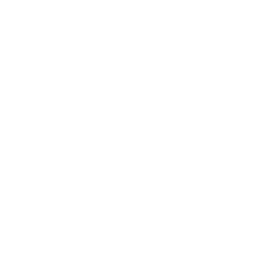
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse des tendances de vote par circonscription</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Administration publique / Statistiques électorales &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Cette analyse examine si l'affiliation partisane varie systématiquement selon
le type de circonscription (urbain, suburbain, rural) dans un jeu de données
électorales simulé de 100 circonscriptions d'un comté. Comme plusieurs
cellules parti x type sont clairsemées — les plus petites cellules du tableau
de contingence ne comptent qu'une ou deux circonscriptions, avec des effectifs
attendus inférieurs à cinq — le test du chi-deux de Pearson omnibus
d'association générale est ici sous-puissant et peu fiable. Nous le
complétons donc par le **test de tendance de Cochran-Armitage**, un test
ciblé à un seul degré de liberté qui exploite l'ordre naturel urbain-rural et
pose une question plus fine : le soutien au Parti A décline-t-il de façon
monotone le long de ce gradient ? Le test de tendance rapporte une valeur p
exacte, l'inférence appropriée lorsque les effectifs de cellule sont faibles.
Le contraste entre les deux tests est le point analytique de cet exemple : un
test d'association générique peut manquer une véritable tendance
directionnelle qu'un test de tendance ordonné détecte.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Enregistrements au niveau circonscription, une ligne par circonscription, avec le type de circonscription, le comté et le parti majoritaire | 100 |

L'environnement d'exécution fonctionne en mode non licencié, ce qui plafonne
la sortie à 100 observations ; l'analyse est dimensionnée autour de cet
échantillon au niveau circonscription afin que les cellules de contingence
soient réellement petites et que le test de tendance exact soit l'outil
naturel.


---

In [1]:
/* --------------------------------------------------------
   Générer des données de vote synthétiques au niveau
   circonscription
   Effectifs de cellule faibles dans les circonscriptions
   rurales pour illustrer le besoin de tests exacts
   -------------------------------------------------------- */
DONNÉES work.precinct_votes;
    APPELER streaminit(42);
    TABLEAU party_list[4] $15 _temporary_ ('PARTI_A' 'PARTI_B' 'PARTI_C' 'INDEPENDANT');
    TABLEAU type_list[3] $10 _temporary_ ('URBAIN' 'SUBURBAIN' 'RURAL');
    TABLEAU county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    FAIRE precinct_seq = 1 JUSQU_À 500;
        precinct_id = cat('PCT-', ÉCRIRE(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Assign precinct type with weighting */
        type_prob = rand('uniform');
        SI type_prob < 0.30 ALORS precinct_type = 'URBAIN';
        SINON SI type_prob < 0.65 ALORS precinct_type = 'SUBURBAIN';
        SINON precinct_type = 'RURAL';
        /* Assign party with type-dependent distribution */
        party_prob = rand('uniform');
        SI precinct_type = 'URBAIN' ALORS FAIRE;
            SI party_prob < 0.55 ALORS party = 'PARTI_A';
            SINON SI party_prob < 0.80 ALORS party = 'PARTI_B';
            SINON SI party_prob < 0.92 ALORS party = 'PARTI_C';
            SINON party = 'INDEPENDANT';
        FIN;
        SINON SI precinct_type = 'SUBURBAIN' ALORS FAIRE;
            SI party_prob < 0.40 ALORS party = 'PARTI_A';
            SINON SI party_prob < 0.75 ALORS party = 'PARTI_B';
            SINON SI party_prob < 0.88 ALORS party = 'PARTI_C';
            SINON party = 'INDEPENDANT';
        FIN;
        SINON FAIRE; /* RURAL - smaller cells for minority parties */
            SI party_prob < 0.25 ALORS party = 'PARTI_A';
            SINON SI party_prob < 0.70 ALORS party = 'PARTI_B';
            SINON SI party_prob < 0.85 ALORS party = 'PARTI_C';
            SINON party = 'INDEPENDANT';
        FIN;
        /* Vote count varies by precinct type */
        SI precinct_type = 'URBAIN' ALORS
            vote_count = int(rand('normal', 120, 40));
        SINON SI precinct_type = 'SUBURBAIN' ALORS
            vote_count = int(rand('normal', 80, 25));
        SINON
            vote_count = int(rand('normal', 25, 12));
        SI vote_count < 1 ALORS vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        SORTIE;
    FIN;
    SUPPRIMER precinct_seq county_idx type_prob party_prob;
EXÉCUTER;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

Type de circonscription    Frequency    Percent
------------------------------------------------
RURAL                             34     34.00
SUBURBAIN                         37     37.00
URBAIN                            29     29.00

Parti          Frequency    Percent
------------------------------------
INDEPENDANT            9      9.00
PARTI_A               45     45.00
PARTI_B               34     34.00
PARTI_C               12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


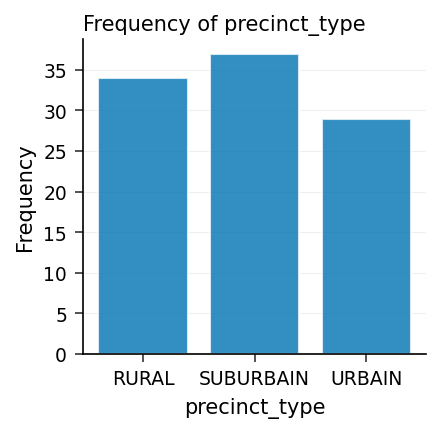

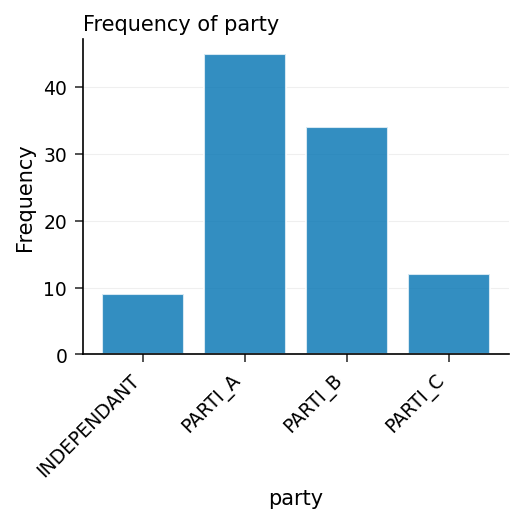

In [2]:
/* --------------------------------------------------------
   Répartition de référence par type de circonscription et
   par parti
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    ÉTIQUETTE precinct_type='Type de circonscription' party='Parti';
EXÉCUTER;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


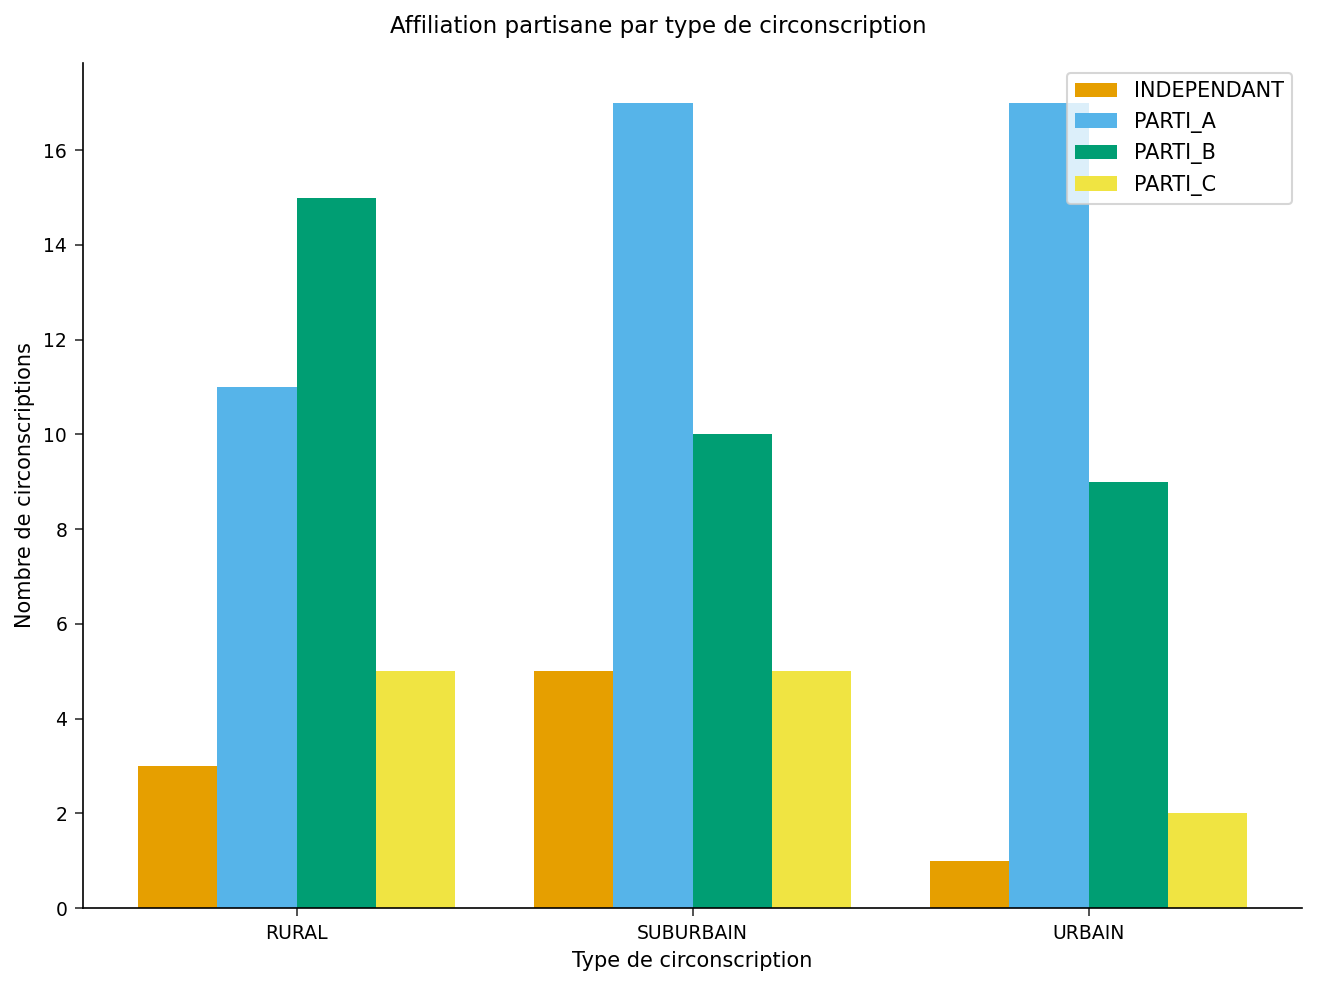

In [3]:
/* --------------------------------------------------------
   Affiliation partisane par type de circonscription
   (effectifs)
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.precinct_votes;
    VBAR precinct_type / GROUPE=party GROUPDISPLAY=GRAPPE
        STAT=FRÉQUENCES;
    XAXIS ÉTIQUETTE='Type de circonscription';
    YAXIS ÉTIQUETTE='Nombre de circonscriptions';
    TITRE 'Affiliation partisane par type de circonscription';
EXÉCUTER;


---

                       Type de circonscription par parti : tableau croisé avec effectifs attendus                       

                                                   The FREQ Procedure

Table of Type de circonscription by Parti

Type de circonscription |INDEPENDANT |    PARTI_A |    PARTI_B |    PARTI_C |       Total
------------------------+------------+------------+------------+------------+------------
RURAL                   |          3 |         11 |         15 |          5 |          34
                        |       3.00 |      11.00 |      15.00 |       5.00 |       34.00
                        |       3.06 |      15.30 |      11.56 |       4.08 |            
                        |       8.82 |      32.35 |      44.12 |      14.71 |      100.00
                        |      33.33 |      24.44 |      44.12 |      41.67 |       34.00
------------------------+------------+------------+------------+------------+------------
SUBURBAIN               |          5 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


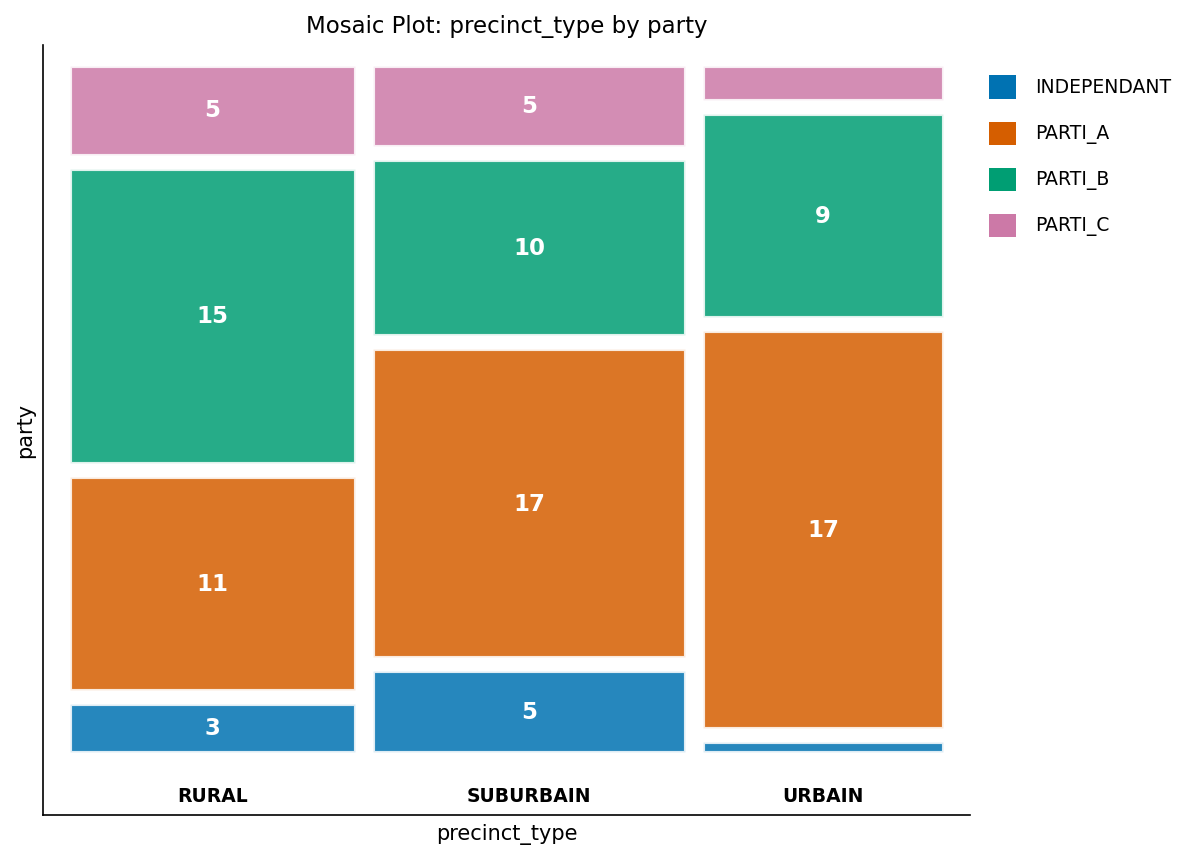

In [4]:
/* --------------------------------------------------------
   Tableau croisé type de circonscription x parti.
   Demande des effectifs ATTENDUS pour rendre visibles les
   cellules clairsemées, plus le test du chi-deux de Pearson
   asymptotique d'association générale. Notez les faibles
   effectifs attendus dans les colonnes INDEPENDANT et
   PARTI_C -- l'indice qu'un test de tendance exact et
   ordonné est le meilleur outil d'inférence.
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    ÉTIQUETTE precinct_type='Type de circonscription' party='Parti';
    TITRE 'Type de circonscription par parti : tableau croisé avec effectifs attendus';
EXÉCUTER;


             Test de tendance de Cochran-Armitage : soutien au Parti A selon le gradient de circonscription             

                                                   The FREQ Procedure

Table of Ordre du type de circonscription (1=Urbain, 2=Suburbain, 3=Rural) by Indicateur Parti A

Ordre du type de circonscription (1=Urbain, 2=Suburbain, 3=Rural) |         0 |         1 |      Total
------------------------------------------------------------------+-----------+-----------+-----------
1                                                                 |        12 |        17 |         29
                                                                  |     12.00 |     17.00 |      29.00
                                                                  |     41.38 |     58.62 |     100.00
                                                                  |     21.82 |     37.78 |      29.00
------------------------------------------------------------------+-----------+-----------+


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


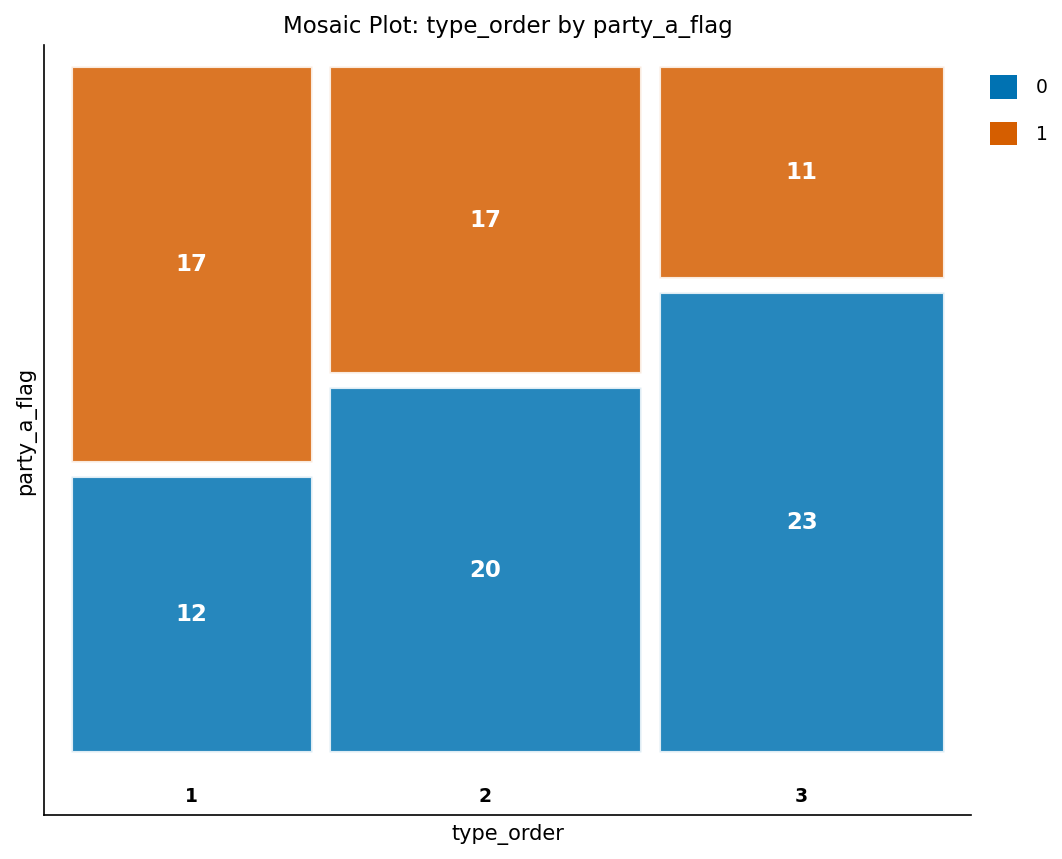

In [5]:
/* --------------------------------------------------------
   Test de tendance de Cochran-Armitage. Recoder le type de
   circonscription en un score ordinal (1=Urbain,
   2=Suburbain, 3=Rural) et tester si le soutien au Parti A
   montre une tendance monotone le long du gradient. EXACT
   TREND demande la valeur p exacte, appropriée compte tenu
   des faibles effectifs de cellule.
   -------------------------------------------------------- */
DONNÉES work.precinct_ordinal;
    DÉFINIR work.precinct_votes;
    /* Codage ordinal : 1=Urbain, 2=Suburbain, 3=Rural */
    SI precinct_type = 'URBAIN' ALORS type_order = 1;
    SINON SI precinct_type = 'SUBURBAIN' ALORS type_order = 2;
    SINON type_order = 3;
    /* Résultat binaire : Parti A contre toutes les autres affiliations */
    party_a_flag = (party = 'PARTI_A');
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    ÉTIQUETTE type_order='Ordre du type de circonscription (1=Urbain, 2=Suburbain, 3=Rural)'
          party_a_flag='Indicateur Parti A';
    TITRE 'Test de tendance de Cochran-Armitage : soutien au Parti A selon le gradient de circonscription';
EXÉCUTER;


                                   Répartition des types de circonscription par comté                                   

                                                   The FREQ Procedure

Table of Comté by Type de circonscription

Comté     |     RURAL | SUBURBAIN |    URBAIN |      Total
----------+-----------+-----------+-----------+-----------
ADAMS     |         5 |        10 |         4 |         19
          |      5.00 |     10.00 |      4.00 |      19.00
          |     26.32 |     52.63 |     21.05 |     100.00
          |     14.71 |     27.03 |     13.79 |      19.00
----------+-----------+-----------+-----------+-----------
HAMILTON  |         7 |         7 |         7 |         21
          |      7.00 |      7.00 |      7.00 |      21.00
          |     33.33 |     33.33 |     33.33 |     100.00
          |     20.59 |     18.92 |     24.14 |      21.00
----------+-----------+-----------+-----------+-----------
JEFFERSON |         4 |         7 |         7 |         


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


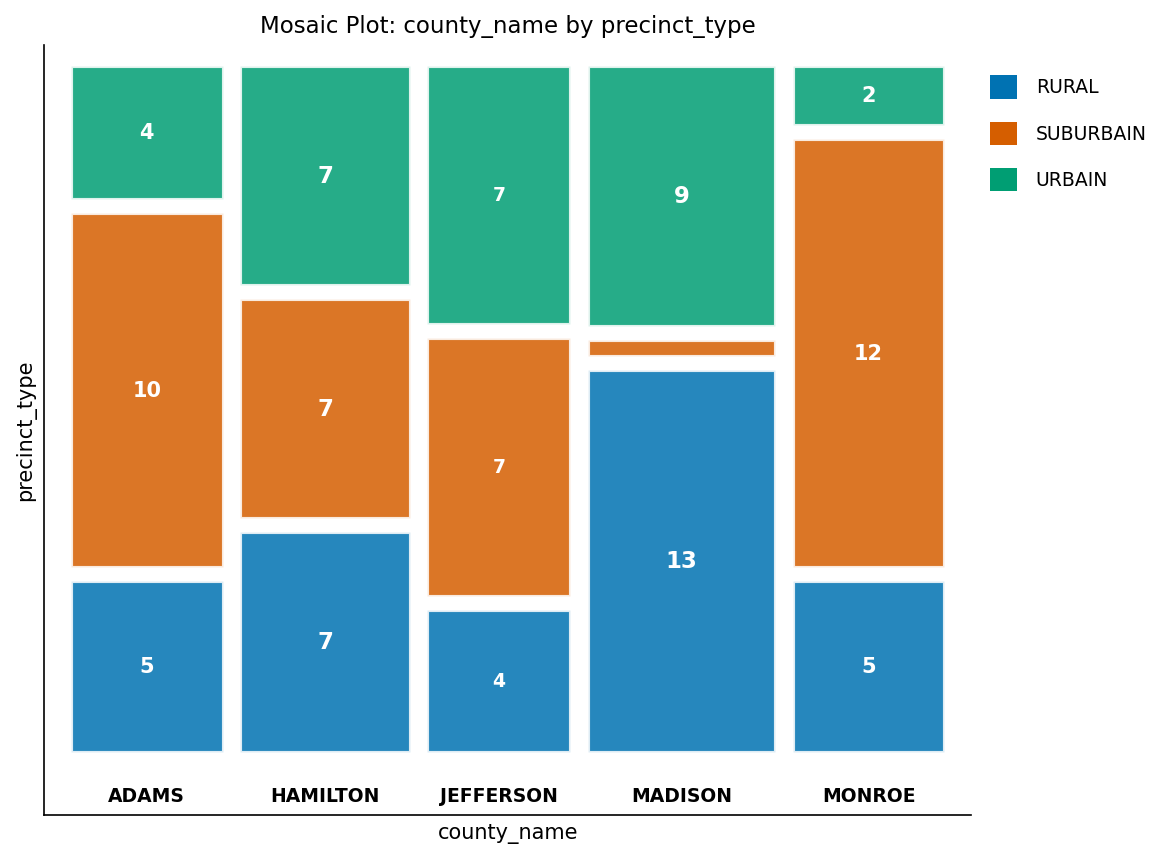

In [6]:
/* --------------------------------------------------------
   Vue au niveau des comtés : comment le mélange urbain/
   suburbain/rural varie selon les cinq comtés. Ceci replace
   le résultat de tendance dans son contexte -- le gradient
   de circonscription est présent dans chaque comté, mais sa
   composition diffère.
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    ÉTIQUETTE county_name='Comté' precinct_type='Type de circonscription';
    TITRE 'Répartition des types de circonscription par comté';
EXÉCUTER;


---

### Interprétation

Sur les 100 circonscriptions, le Parti A détient la majorité relative dans
l'ensemble (45 circonscriptions), suivi du Parti B (34), du Parti C (12) et
des Indépendants (9). Le tableau croisé montre que la part du Parti A suit un
net gradient urbain-rural : il représente 58,6 % des circonscriptions
urbaines, 46,0 % des circonscriptions suburbaines et 32,4 % des
circonscriptions rurales, tandis que le Parti B évolue en sens inverse,
passant de 31,0 % en zone urbaine à 44,1 % en zone rurale.

Le test du chi-deux de Pearson omnibus d'association générale n'est **pas**
statistiquement significatif (chi-deux = 6,78, 6 ddl, p = 0,3418 ; V de
Cramer = 0,18). Ce résultat est également fragile : l'affichage des effectifs
attendus révèle plusieurs cellules inférieures à cinq — par exemple, la
colonne Indépendants affiche des effectifs attendus de 3,06, 3,33 et 2,61, et
les Indépendants en zone urbaine ne comptent qu'une seule circonscription —
si bien que l'approximation du chi-deux en grand échantillon n'est pas
fiable ici.

Le test de tendance de Cochran-Armitage affine la question en utilisant le
score ordinal urbain-suburbain-rural. Il détecte le déclin monotone du
soutien au Parti A que le test omnibus ne détecte pas : chi-deux de tendance
= 4,38 avec un Pr > ChiSq asymptotique = 0,0363 et un **Pr >= |Z| exact =
0,0431**, significatif au seuil de 0,05. C'est là le gain analytique — un
test ciblé, exact, à un seul degré de liberté retrouve un véritable signal
directionnel que le test d'association générique à 6 degrés de liberté,
affaibli par des cellules clairsemées, ne détecte pas.

La vue au niveau des comtés confirme que la répartition urbain/suburbain/
rural est présente dans les cinq comtés, bien que le mélange diffère :
Madison est le plus rural (13 des 23 circonscriptions rurales) tandis que
Monroe est le plus suburbain (12 sur 19). Pour l'évaluation de l'impact d'un
redécoupage électoral, le message est que des changements de limites
déplaçant des circonscriptions le long de l'axe urbain-rural modifieraient
sensiblement la composition partisane, et que cette tendance géographique est
mieux mise en évidence par le test de tendance exact que par le chi-deux
omnibus.


---

                                   Répartition des types de circonscription par comté                                   

                                                   The FREQ Procedure

Table of Type de circonscription by Parti

Type de circonscription |INDEPENDANT |    PARTI_A |    PARTI_B |    PARTI_C |       Total
------------------------+------------+------------+------------+------------+------------
RURAL                   |          3 |         11 |         15 |          5 |          34
                        |       3.00 |      11.00 |      15.00 |       5.00 |       34.00
                        |       8.82 |      32.35 |      44.12 |      14.71 |      100.00
                        |      33.33 |      24.44 |      44.12 |      41.67 |       34.00
------------------------+------------+------------+------------+------------+------------
SUBURBAIN               |          5 |         17 |         10 |          5 |          37
                        |       5.00 |      


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


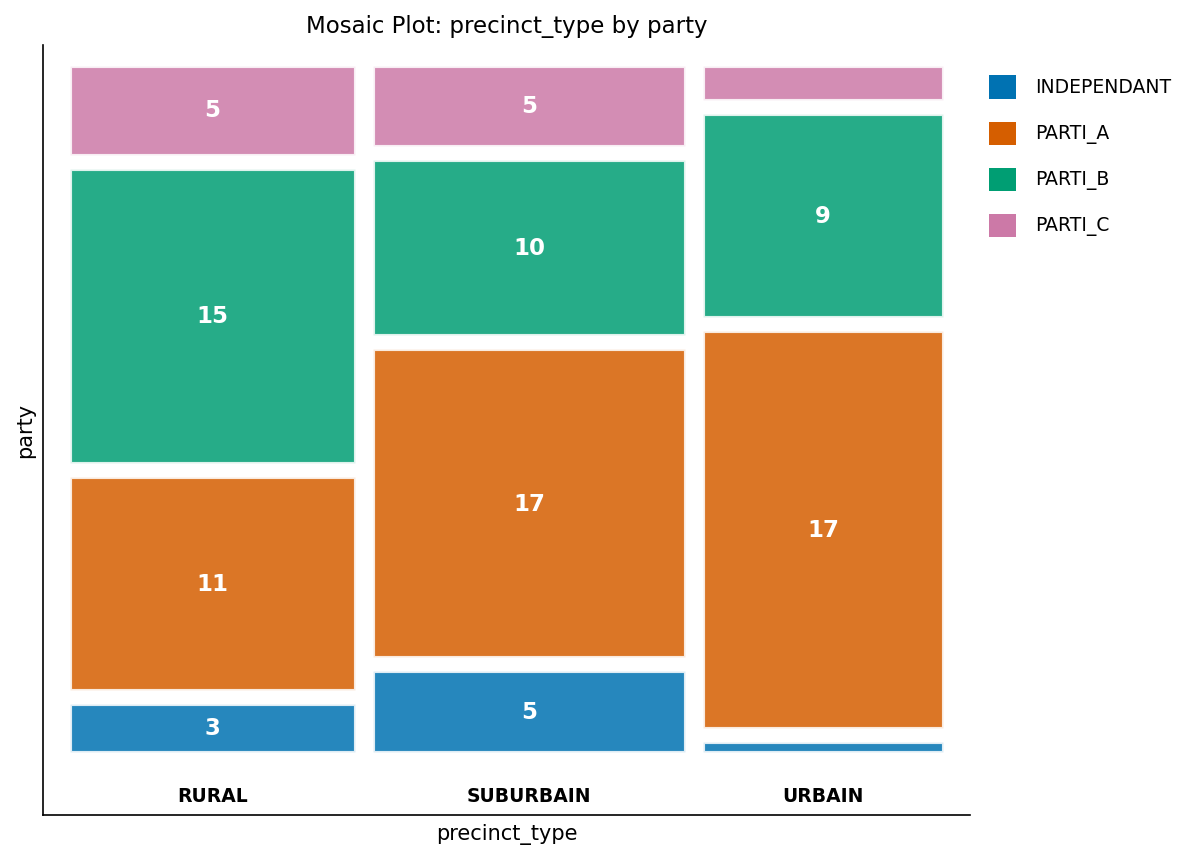

In [7]:
/* --------------------------------------------------------
   Exporter la synthèse type de circonscription x parti pour
   l'évaluation en aval de l'impact du redécoupage électoral.
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    ÉTIQUETTE precinct_type='Type de circonscription' party='Parti';
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>